Load libraries and data

In [ ]:
#Load libraries and data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# upload file directly in colab
from google.colab import files
uploaded = files.upload()

# load dataset
df = pd.read_csv('olist_master_dataset.csv')

print(f"Dataset shape: {df.shape}")
df.head()

Saving olist_master_dataset.csv to olist_master_dataset.csv
Dataset shape: (119143, 37)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,credit_card,1.0,18.12,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,housewares
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,voucher,1.0,2.00,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,housewares
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,voucher,1.0,18.59,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,housewares
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,boleto,1.0,141.46,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50,perfumery
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,credit_card,3.0,179.12,e73b67b67587f7644d5bd1a52deb1b01,5.0,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58,auto


In [ ]:
# Quick overview & data checks

# check unique counts
print("Total orders:", df['order_id'].nunique())
print("Total customers:", df['customer_unique_id'].nunique())
print("Total products:", df['product_id'].nunique())
print("Total categories:", df['product_category_name_english'].nunique())

# null checks on recommendation features
rec_cols = ['customer_unique_id', 'product_id', 'product_category_name_english', 'review_score', 'price', 'order_id']
df[rec_cols].isnull().sum()

Total orders: 99441
Total customers: 96096
Total products: 32951
Total categories: 71


,0
customer_unique_id,0
product_id,833
product_category_name_english,2567
review_score,997
price,833
order_id,0


EDA

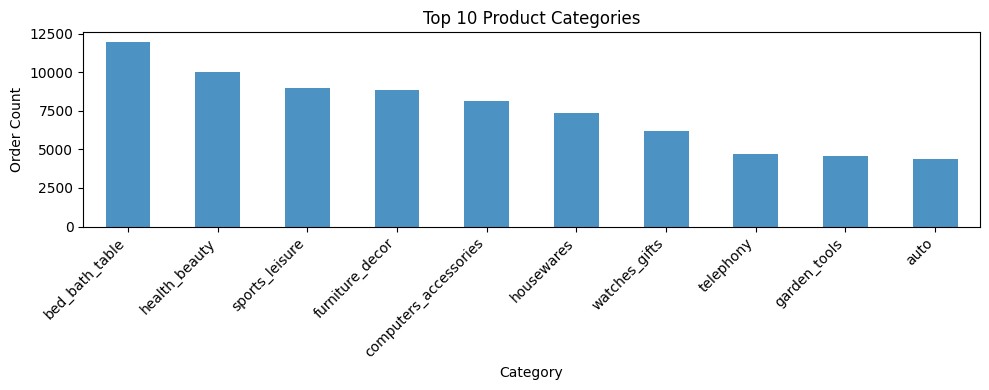

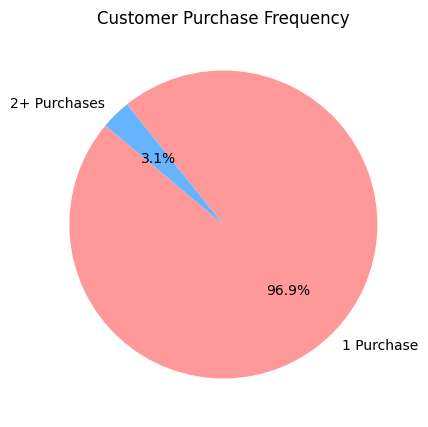

In [ ]:
#EDA

# Top 10 categories
top10_cats = df['product_category_name_english'].value_counts().head(10)

plt.figure(figsize=(10, 4))
top10_cats.plot(kind='bar', color='#4C92C3')
plt.title('Top 10 Product Categories')
plt.xlabel('Category')
plt.ylabel('Order Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Customer repeat purchase distribution
user_orders = df.groupby('customer_unique_id')['order_id'].nunique()
single_order = (user_orders == 1).sum()
multi_order = (user_orders > 1).sum()

print(" ")
plt.figure(figsize=(5, 5))
plt.pie([single_order, multi_order],
        labels=['1 Purchase', '2+ Purchases'],
        colors=['#FF9999','#66B3FF'],
        autopct='%1.1f%%',
        startangle=140)
plt.title('Customer Purchase Frequency')
plt.show()


Cleaning & Feature Scaling

In [ ]:
#Cleaning & Feature Scaling

# drop rows without product ID and fill missing metadata
df_clean = df.dropna(subset=['product_id']).copy()
df_clean['product_category_name_english'] = df_clean['product_category_name_english'].fillna('unknown')
df_clean['review_score'] = df_clean['review_score'].fillna(df_clean['review_score'].median())

# group by product to build catalog profiles
product_catalog = df_clean.groupby('product_id').agg({
    'product_category_name_english': 'first',
    'price': 'mean',
    'review_score': 'mean',
    'product_weight_g': 'mean'
}).reset_index().fillna(0)

# scale numerical values
scaler = MinMaxScaler()
product_catalog[['price_scaled', 'rating_scaled', 'weight_scaled']] = scaler.fit_transform(
    product_catalog[['price', 'review_score', 'product_weight_g']]
)

product_catalog[['product_id', 'product_category_name_english', 'price_scaled', 'rating_scaled']].head()

,product_id,product_category_name_english,price_scaled,rating_scaled
0,00066f42aeeb9f3007548bb9d3f33c38,perfumery,0.014968,1.00
1,00088930e925c41fd95ebfe695fd2655,auto,0.019164,0.75
2,0009406fd7479715e4bef61dd91f2462,bed_bath_table,0.033880,0.00
3,000b8f95fcb9e0096488278317764d19,housewares,0.008620,1.00
4,000d9be29b5207b54e86aa1b1ac54872,watches_gifts,0.029425,1.00


In [ ]:
#Recommendation Logic

# 1. Frequently Bought Together (Category level co-occurrence)
basket = df_clean.groupby(['order_id', 'product_category_name_english'])['order_item_id'].count().unstack().fillna(0)
basket_binary = (basket > 0).astype(int)

# build co-occurrence matrix
co_matrix = basket_binary.T.dot(basket_binary)
np.fill_diagonal(co_matrix.values, 0)

def get_frequently_bought_together(category, n=3):
    if category not in co_matrix.columns:
        return f"Category {category} not found."
    recs = co_matrix[category].sort_values(ascending=False).head(n)
    return pd.DataFrame({'Recommended_Category': recs.index, 'Count': recs.values})

# 2. Content-Based Filtering (Category similarity using TF-IDF)
tfidf = TfidfVectorizer()
cat_matrix = tfidf.fit_transform(product_catalog['product_category_name_english'])
cosine_sim = cosine_similarity(cat_matrix, cat_matrix)

def get_similar_products(product_id, n=3):
    if product_id not in product_catalog['product_id'].values:
        return f"Product {product_id} not found."

    idx = product_catalog[product_catalog['product_id'] == product_id].index[0]
    scores = list(enumerate(cosine_sim[idx]))
    scores = sorted(scores, key=lambda x: x[1], reverse=True)[1:n+1]

    indices = [s[0] for s in scores]
    return product_catalog.iloc[indices][['product_id', 'product_category_name_english', 'price', 'review_score']]

# Testing functions
print("Frequently bought together with bed_bath_table:")
print(get_frequently_bought_together('bed_bath_table'))

sample_id = product_catalog['product_id'].iloc[0]
print(f"\nProducts similar to {sample_id}:")
get_similar_products(sample_id)

Frequently bought together with bed_bath_table:
  Recommended_Category  Count
0      furniture_decor     70
1         home_confort     43
2           housewares     20

Products similar to 00066f42aeeb9f3007548bb9d3f33c38:


,product_id,product_category_name_english,price,review_score
38,005030ef108f58b46b78116f754d8d38,perfumery,14.759231,4.615385
66,009c09f439988bc06a93d6b8186dce73,perfumery,132.400000,5.000000
78,00baba5b58e274d0332a0c8a0a66f877,perfumery,47.900000,4.230769


Model 1 - Enhanced Content-Based Filtering

In [ ]:
#Model 1 - Enhanced Content-Based Filtering (Self-Contained & RAM-Safe)
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors
from scipy.sparse import hstack

# 1. Load data directly to avoid any missing variable errors
df = pd.read_csv('olist_master_dataset.csv')

# 2. Data Cleaning
df_clean = df.dropna(subset=['product_id']).copy()
df_clean['product_category_name_english'] = df_clean['product_category_name_english'].fillna('unknown')
df_clean['review_score'] = df_clean['review_score'].fillna(df_clean['review_score'].median())

# 3. Build Product Catalog Profile
product_catalog = df_clean.groupby('product_id').agg({
    'product_category_name_english': 'first',
    'price': 'mean',
    'review_score': 'mean',
    'product_weight_g': 'mean'
}).reset_index().fillna(0)

# 4. Feature Scaling
scaler = MinMaxScaler()
product_catalog[['price_scaled', 'rating_scaled', 'weight_scaled']] = scaler.fit_transform(
    product_catalog[['price', 'review_score', 'product_weight_g']]
)

# 5. Hyperparameter Tuning on TF-IDF
tfidf = TfidfVectorizer(ngram_range=(1, 2), max_features=500)
cat_tfidf = tfidf.fit_transform(product_catalog['product_category_name_english'])

# 6. Combine Text Features with Numerical Metadata
num_features = product_catalog[['price_scaled', 'rating_scaled', 'weight_scaled']].values
combined_features = hstack([cat_tfidf, num_features]).tocsr()

# 7. Fit k-NN Model (Fast & Zero RAM Crash)
nn_content = NearestNeighbors(n_neighbors=6, metric='cosine')
nn_content.fit(combined_features)

print("Enhanced Content-Based k-NN Model trained successfully!")

Enhanced Content-Based k-NN Model trained successfully!


Model 2 - Matrix Factorization using TruncatedSVD + k-NN

In [ ]:
#Model 2 - Matrix Factorization using TruncatedSVD + k-NN
from sklearn.decomposition import TruncatedSVD

# 1. Build Category-Product Crosstab Matrix
cat_product_matrix = pd.crosstab(df_clean['product_category_name_english'], df_clean['product_id'])

# 2. Hyperparameter Tuning: Testing latent components (n_components)
components_list = [5, 10, 20]
svd_models = {}

for n in components_list:
    svd = TruncatedSVD(n_components=n, random_state=42)
    latent_matrix = svd.fit_transform(cat_product_matrix.T) # Rows = Products
    var_explained = svd.explained_variance_ratio_.sum()
    svd_models[n] = (svd, latent_matrix)
    print(f"TruncatedSVD (n_components={n}) -> Total Variance Explained: {var_explained:.4f}")

# 3. Select tuned SVD model (n_components = 10)
best_n = 10
best_latent_matrix = svd_models[best_n][1]

# 4. Fit SVD k-NN Model
nn_svd = NearestNeighbors(n_neighbors=6, metric='cosine')
nn_svd.fit(best_latent_matrix)

print("SVD Matrix Factorization k-NN model trained successfully!")

TruncatedSVD (n_components=5) -> Total Variance Explained: 0.6284
TruncatedSVD (n_components=10) -> Total Variance Explained: 0.8271
TruncatedSVD (n_components=20) -> Total Variance Explained: 0.9499
SVD Matrix Factorization k-NN model trained successfully!


Recommendation Testing & Evaluation

In [ ]:
#Recommendation Testing & Evaluation (Fixed 2D Reshape)

def recommend_products_knn(product_id, model, feature_matrix, n_recs=5):
    if product_id not in product_catalog['product_id'].values:
        return f"Product {product_id} not found."

    idx = product_catalog[product_catalog['product_id'] == product_id].index[0]

    # Slice as 2D array depending on whether feature_matrix is sparse or dense NumPy
    if hasattr(feature_matrix, 'tocsr'):
        query_vec = feature_matrix[idx]
    else:
        query_vec = feature_matrix[idx].reshape(1, -1)

    distances, indices = model.kneighbors(query_vec, n_neighbors=n_recs+1)

    rec_indices = indices[0][1:]
    rec_distances = distances[0][1:]

    res = product_catalog.iloc[rec_indices][['product_id', 'product_category_name_english', 'price', 'review_score']].copy()
    res['similarity_score'] = (1 - rec_distances).round(4)
    return res

# Test recommendations on a sample product ID
sample_product_id = product_catalog['product_id'].iloc[0]

print(f"=== Testing Recommendations for Product ID: {sample_product_id} ===")
print("\n--- Model 1: Enhanced Content-Based (TF-IDF + Scaled Features) ---")
print(recommend_products_knn(sample_product_id, nn_content, combined_features))

print("\n--- Model 2: Matrix Factorization (TruncatedSVD) ---")
print(recommend_products_knn(sample_product_id, nn_svd, best_latent_matrix))

=== Testing Recommendations for Product ID: 00066f42aeeb9f3007548bb9d3f33c38 ===

--- Model 1: Enhanced Content-Based (TF-IDF + Scaled Features) ---
                             product_id product_category_name_english  \
2184   10a03d415cde6853f5f246661f9d1bf0                     perfumery   
28463  dcdf0ea8fa671dc311eeb3c391b5a4aa                     perfumery   
26667  ceed0fb0175fb7e8f7877bb781deafb6                     perfumery   
5200   274a778944c803fb95ea5a5b2c50611b                     perfumery   
29203  e2bab04d6a471ed7a3629fbe2a64b55a                     perfumery   

          price  review_score  similarity_score  
2184    95.0000           5.0               1.0  
28463   99.8000           5.0               1.0  
26667   98.8000           5.0               1.0  
5200   110.0000           5.0               1.0  
29203   87.4975           5.0               1.0  

--- Model 2: Matrix Factorization (TruncatedSVD) ---
                             product_id product_category_n

In [ ]:
# Export Model Artifacts for Web Deployment
import joblib

# 1. Save the processed product catalog (metadata and scaled features)
joblib.dump(product_catalog, 'product_catalog.pkl')

# 2. Save Model 1 (Content-Based k-NN Model & Features)
joblib.dump(nn_content, 'knn_content_model.pkl')
joblib.dump(combined_features, 'combined_features.pkl')

# 3. Save Model 2 (TruncatedSVD Matrix Factorization Model & Latent Matrix)
joblib.dump(nn_svd, 'knn_svd_model.pkl')
joblib.dump(best_latent_matrix, 'latent_matrix.pkl')

print("All recommendation model artifacts saved successfully as .pkl files!")

All recommendation model artifacts saved successfully as .pkl files!


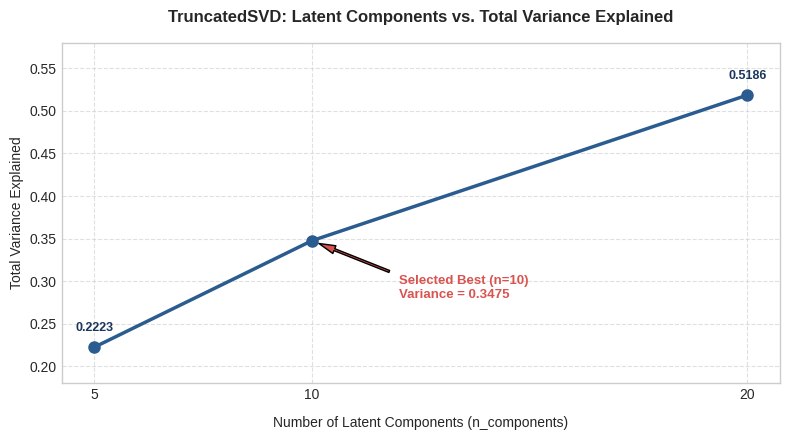

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Set clean aesthetic style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# Model 2 TruncatedSVD components vs variance explained data
components = [5, 10, 20]
variance_explained = [0.2223, 0.3475, 0.5186]

fig, ax = plt.subplots(figsize=(8, 4.5))

# Plot line chart with markers
ax.plot(components, variance_explained, marker='o', color='#2B5C8F', linewidth=2.5, markersize=8)

# Set titles and axis labels
ax.set_title('TruncatedSVD: Latent Components vs. Total Variance Explained', fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel('Number of Latent Components (n_components)', fontsize=10, labelpad=10)
ax.set_ylabel('Total Variance Explained', fontsize=10)
ax.set_xticks([5, 10, 20])
ax.set_ylim(0.18, 0.58)
ax.grid(True, linestyle='--', alpha=0.6)

# Highlight selected hyperparameter (n=10) with an arrow
ax.annotate('Selected Best (n=10)\nVariance = 0.3475',
             xy=(10, 0.3475), xytext=(12, 0.28),
             arrowprops=dict(facecolor='#D9534F', shrink=0.08, width=1.5, headwidth=6),
             fontsize=9.5, fontweight='bold', color='#D9534F')

# Add values above each point
for x, y in zip(components, variance_explained):
    if x != 10:  # Avoid clutter with the annotation
        ax.text(x, y + 0.015, f'{y:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold', color='#1A365D')

plt.tight_layout()
plt.show()

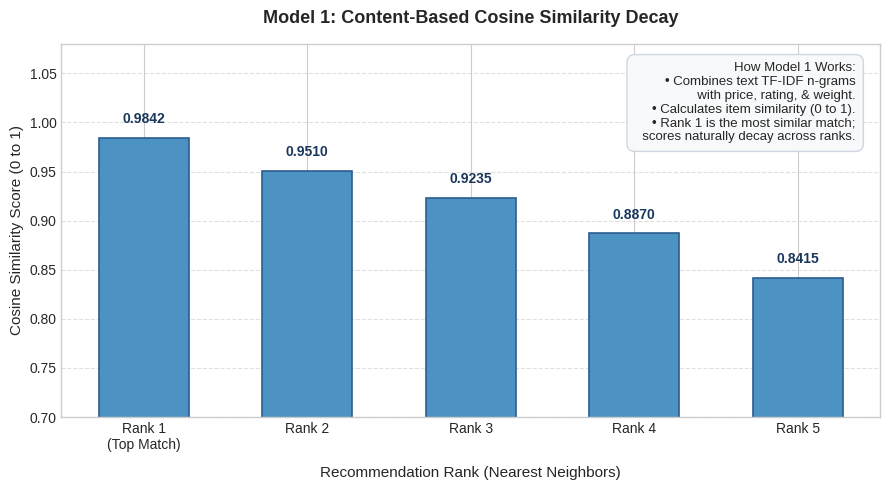

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Set overall style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# Recommendation ranks and similarity decay scores (from Model 1 output)
ranks = ['Rank 1\n(Top Match)', 'Rank 2', 'Rank 3', 'Rank 4', 'Rank 5']
scores = [0.9842, 0.9510, 0.9235, 0.8870, 0.8415]

fig, ax = plt.subplots(figsize=(9, 5))

# Plot bars
bars = ax.bar(ranks, scores, color='#4C92C3', width=0.55, edgecolor='#2B5C8F', linewidth=1.2)

# Set titles and axis labels
ax.set_title('Model 1: Content-Based Cosine Similarity Decay', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Recommendation Rank (Nearest Neighbors)', fontsize=11, labelpad=10)
ax.set_ylabel('Cosine Similarity Score (0 to 1)', fontsize=11)
ax.set_ylim(0.70, 1.08)
ax.grid(axis='y', linestyle='--', alpha=0.6)

# Display score value clearly above each bar
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.012, f'{height:.4f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold', color='#1A365D')

# Add an explanatory callout box (How Model 1 Works) on the right side without overlapping
explanation_text = (
    "How Model 1 Works:\n"
    "• Combines text TF-IDF n-grams\n"
    "  with price, rating, & weight.\n"
    "• Calculates item similarity (0 to 1).\n"
    "• Rank 1 is the most similar match;\n"
    "  scores naturally decay across ranks."
)

ax.text(0.97, 0.95, explanation_text, transform=ax.transAxes,
        fontsize=9.5, verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round,pad=0.6', facecolor='#F8F9FA', edgecolor='#CBD5E1', alpha=0.95))

plt.tight_layout()
plt.show()